In [1]:
from cytoflow import *
%matplotlib inline

In [2]:
'''
For Jean:
Each tube has a DNA label.
'''

# make paths relative so stuff will work for Jean and Charles
import os
data_folder = os.path.join(os.getcwd(), 'example_data')

op_0 = ImportOp(
    conditions={'TUBE_NAME': 'category'},
    tubes=[
        Tube(
            file=
            os.path.join(data_folder, 'L2vsCoTX/E20220430A_CasE-R+pGW42_010.fcs'),
            conditions={'TUBE_NAME': 'CasE-R+pGW42'}),
        Tube(
            file=
            os.path.join(data_folder, 'L2vsCoTX/E20220430A_CoTX-All_009.fcs'),
            conditions={'TUBE_NAME': 'CoTX-All'}),
        Tube(
            file=
            os.path.join(data_folder, 'L2vsCoTX/E20220430A_L2all_pGW42+10_012.fcs'),
            conditions={'TUBE_NAME': 'L2all_pGW42+10'}),
        Tube(
            file=
            os.path.join(data_folder, 'L2vsCoTX/E20220430A_NW-B+pGW10_011.fcs'),
            conditions={'TUBE_NAME': 'NW-B+pGW10'}),
        Tube(
            file=
            os.path.join(data_folder, 'Beads+Ctrls/E20220430A_Empty_001.fcs'),
            conditions={'TUBE_NAME': 'Empty'})
    ],
    channels={
        'FITC-A': 'FITC_A',
        'FSC-A': 'FSC_A',
        'FSC-H': 'FSC_H',
        'FSC-W': 'FSC_W',
        'PE-Texas Red-A': 'PE_Texas_Red_A',
        'Pacific Blue-A': 'Pacific_Blue_A',
        'SSC-A': 'SSC_A',
        'SSC-H': 'SSC_H',
        'SSC-W': 'SSC_W',
        'Time': 'Time'
    })

ex_0 = op_0.apply()


In [3]:
op_1 = GaussianMixtureOp(name='Cells',
                         channels=['FSC_A', 'SSC_A'],
                         scale={
                             'FSC_A': 'log',
                             'SSC_A': 'log'
                         },
                         num_components=3)

op_1.estimate(ex_0)
ex_1 = op_1.apply(ex_0)


/Users/georgwachter/opt/anaconda3/envs/cytoflow/lib/python3.8/site-packages/cytoflow/operations/base_op_views.py:373: CytoflowViewWarning: Setting 'huefacet' to 'Cells'


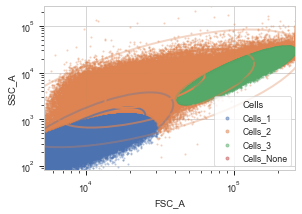

In [4]:
op_1.default_view().plot(ex_1)


In [5]:
op_2 = PolygonOp(name='SingletsSSC',
                 xchannel='SSC_W',
                 ychannel='SSC_H',
                 vertices=[(70804.80649141644, 6827.122701173415),
                           (69504.34267177846, 4723.323628490771),
                           (69647.65101982164, 3320.5787571830033),
                           (70513.72759774125, 2242.7953621743277),
                           (75008.36048973077, 1895.6176073834315),
                           (80449.58450105172, 1910.8595957452876),
                           (89544.62820235682, 2590.5646439419215),
                           (97837.30244771566, 3655.529629064642),
                           (104718.65828293862, 4955.8250292290495),
                           (110479.55981448611, 6665.052544427531),
                           (112084.01211224224, 10271.123031489207),
                           (110025.37782264041, 13485.63538786984),
                           (103645.72710513268, 15576.726627006532),
                           (93888.8033199642, 15828.22755331319),
                           (87719.107535262, 15329.221897729518),
                           (81617.922978531, 13378.067098660198),
                           (76411.80745775548, 11127.519583955433),
                           (72876.28180494525, 9181.746987071001)],
                 xscale='log',
                 yscale='log')

ex_2 = op_2.apply(ex_1)


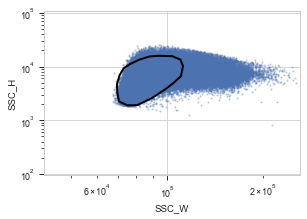

In [6]:
op_2.default_view(subset='(Cells == "Cells_3")').plot(ex_1)


In [7]:
op_3 = PolygonOp(name='SingletsFSC',
                 xchannel='FSC_W',
                 ychannel='FSC_H',
                 vertices=[(86602.9766434866, 66391.37510744638),
                           (84504.68540082434, 61010.23910979671),
                           (82204.81480895882, 53223.52999021064),
                           (81577.1438458329, 45238.64266821911),
                           (82457.23335918813, 40242.20853677077),
                           (84634.32623081577, 36031.12422214863),
                           (86868.90021330054, 33544.120139896266),
                           (91376.41926995142, 31330.467763310884),
                           (99719.93646337722, 29936.46584614476),
                           (110168.10160177351, 30427.056383047267),
                           (116776.2265417388, 32471.14350193249),
                           (125116.12130586928, 36740.842095033666),
                           (133436.564434754, 43366.57237310787),
                           (137169.7621937448, 53920.16394445157),
                           (136749.85734006847, 62617.797032378716),
                           (134257.28463412303, 72955.19914789018),
                           (131004.38391950788, 78875.37186312354),
                           (127634.48989323174, 82013.2469127403),
                           (123212.77917695322, 84174.21278920562),
                           (118944.25217829528, 86111.71501344358),
                           (115176.18004613591, 85275.95509587407),
                           (108825.29439988699, 83628.69101568947),
                           (100950.39165849616, 80690.90661371431),
                           (93358.67126713418, 75857.55375793549)],
                 xscale='log',
                 yscale='log')

ex_3 = op_3.apply(ex_2)


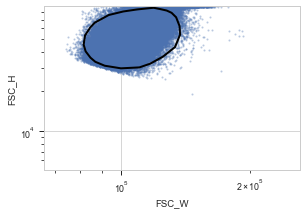

In [8]:
op_3.default_view(
    subset='(Cells == "Cells_3") and (SingletsSSC == True)').plot(ex_2)


In [9]:
op_4 = AutofluorescenceOp(
    channels=['PE_Texas_Red_A', 'Pacific_Blue_A', 'FITC_A'],
    blank_file=
    '/Users/georgwachter/Desktop/GitHub/weiss-visit/Results/By_E_Number/E20220522A_L2vsCoTXandpC31/Beads+Ctrls/E20220430A_Empty_001.fcs'
)

op_4.estimate(
    ex_3,
    subset=
    '(Cells == "Cells_3") and (SingletsFSC == True) and (SingletsSSC == True)')
ex_4 = op_4.apply(ex_3)


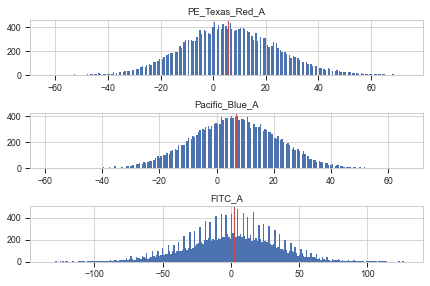

In [10]:
op_4.default_view().plot(ex_3)


In [25]:
op_5 = BleedthroughLinearOp(
    controls={
        'Pacific_Blue_A':
        os.path.join(data_folder, 'Beads+Ctrls/E20220430A_B_002.fcs'),
        'FITC_A':
        os.path.join(data_folder, 'Beads+Ctrls/E20220430A_Y_003.fcs'),
        'PE_Texas_Red_A':
        os.path.join(data_folder, 'Beads+Ctrls/E20220430A_R_004.fcs')
    })

op_5.estimate(
    ex_4,
    subset=
    '(Cells == "Cells_3") and (SingletsFSC == True) and (SingletsSSC == True)')
ex_5 = op_5.apply(ex_4)


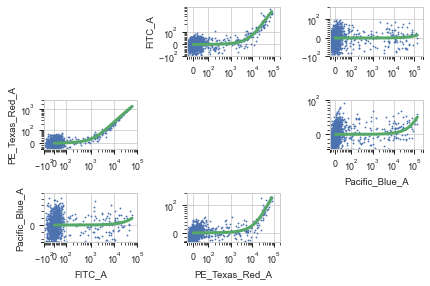

In [12]:
op_5.default_view().plot(ex_4)


In [26]:
# Beads: RCP-30-5A Lot AN04, AN03, AN02, AN01, AM02, AM01, AL01, AK04, AK03 & AK02
op_6 = BeadCalibrationOp(
    units={
        'Pacific_Blue_A': 'MEBFP',
        'PE_Texas_Red_A': 'MEPTR',
        'FITC_A': 'MEFL'
    },
    beads_file=
    os.path.join(data_folder, 'Beads+Ctrls/E20220430A_9peaks_016.fcs'),
    beads={
        'MECSB': [
            205.139224587675, 470.418789207962, 1211.03409137091,
            2739.85605412079, 7516.43849705557, 20121.7589207813,
            35572.7129888405
        ],
        'MEBFP': [
            843.503722117931, 1957.71825828363, 5421.80193415564,
            13522.433084656, 42717.4973739119, 153501.022826764,
            420359.287816952
        ],
        'MEFL': [
            771.204227758779, 2106.46973727296, 6262.29508551021,
            15182.5413019226, 45291.7071432442, 136257.847794468,
            291041.740879689
        ],
        'MEPE': [
            487.398484275159, 1473.64215674594, 4516.24975517653,
            11260.0753555562, 34341.0801281963, 107608.01291543,
            260461.299924314
        ],
        'MEPTR': [
            204.868534691815, 643.202193579403, 2021.09484018683,
            5278.32442121266, 17017.8228394271, 62450.9816067639,
            198932.678535898
        ],
        'MECY': [
            1414.42033101552, 3808.80637667958, 10852.1944856379,
            27904.3884607569, 85866.2647607231, 324106.419847251,
            1040895.428772
        ],
        'MEPCY7': [
            12752.0445894082, 39056.5340076057, 142957.954887933,
            448890.055464371
        ],
        'MEAP': [
            341.010388310164, 1027.34896530879, 3155.71287209302,
            7750.10141500535, 23446.4537774744, 68701.80510944,
            116813.097393489
        ],
        'MEAPCY7': [
            173.309661734951, 427.442877227215, 1097.43242546677,
            2399.15279284361, 6359.25563563231, 17474.9563255425,
            30725.4485529926
        ]
    })

op_6.estimate(ex_5)
ex_6 = op_6.apply(ex_5)


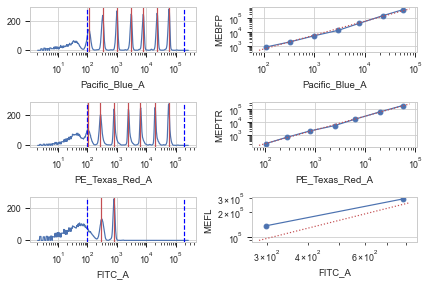

In [14]:
op_6.default_view().plot(ex_5)


In [15]:
op_7 = BinningOp(name='mKateBins',
                 channel='PE_Texas_Red_A',
                 bin_width=0.5,
                 scale='log')

ex_7 = op_7.apply(ex_6)


/Users/georgwachter/opt/anaconda3/envs/cytoflow/lib/python3.8/site-packages/cytoflow/operations/base_op_views.py:373: CytoflowViewWarning: Setting 'huefacet' to 'mKateBins'


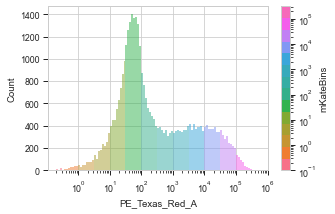

In [16]:
op_7.default_view(
    subset=
    '(Cells == "Cells_3") and (SingletsFSC == True) and (SingletsSSC == True) and (TUBE_NAME == "CoTX-All")',
    huescale='log').plot(ex_7)


In [17]:
op_8 = BinningOp(name='eBFPbins',
                 channel='Pacific_Blue_A',
                 bin_width=0.5,
                 scale='log')

ex_8 = op_8.apply(ex_7)


/Users/georgwachter/opt/anaconda3/envs/cytoflow/lib/python3.8/site-packages/cytoflow/operations/base_op_views.py:373: CytoflowViewWarning: Setting 'huefacet' to 'eBFPbins'


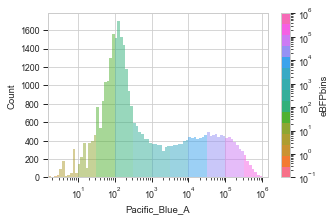

In [18]:
op_8.default_view(
    subset=
    '(Cells == "Cells_3") and (SingletsFSC == True) and (SingletsSSC == True) and (TUBE_NAME == "CoTX-All")',
    huescale='log').plot(ex_8)


In [19]:
op_9 = BinningOp(name='eYFPbins', channel='FITC_A', bin_width=0.5, scale='log')

ex_9 = op_9.apply(ex_8)


/Users/georgwachter/opt/anaconda3/envs/cytoflow/lib/python3.8/site-packages/cytoflow/operations/base_op_views.py:373: CytoflowViewWarning: Setting 'huefacet' to 'eYFPbins'


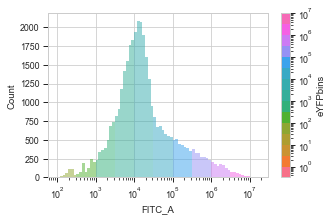

In [20]:
op_9.default_view(
    subset=
    '(Cells == "Cells_3") and (SingletsFSC == True) and (SingletsSSC == True) and (TUBE_NAME == "CoTX-All")',
    huescale='log').plot(ex_9)


Begin with Jupyter NB analysis
------------------------------

In [21]:
# imports
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from geostruct import flowgeo  # IMPORT FROM FILE (helper functions to deal with data formatting, cleaning, processing, and plotting)



In [22]:
df = ex_9.data
df.head()

,FSC_A,FSC_H,FSC_W,SSC_A,SSC_H,SSC_W,TUBE_NAME,Time,Cells,SingletsSSC,SingletsFSC,Pacific_Blue_A,PE_Texas_Red_A,FITC_A,mKateBins,eBFPbins,eYFPbins
0,79822.398438,54384.0,96190.804688,4975.850098,3936.0,82849.929688,CasE-R+pGW42,55.700001,Cells_3,True,True,36.459855,29.341402,7.875463e+03,10.000,31.62,3162.0
1,122178.695312,66187.0,120976.976562,10233.899414,6609.0,101481.132812,CasE-R+pGW42,56.799999,Cells_3,True,True,36.555612,9.849771,1.766232e+04,3.162,31.62,10000.0
2,59141.597656,38889.0,99665.812500,5961.889648,4557.0,85740.273438,CasE-R+pGW42,58.900002,Cells_3,True,True,81.443252,34.401394,5.494490e+03,31.620,31.62,3162.0
3,83779.500000,48355.0,113547.179688,5046.399902,3847.0,85968.507812,CasE-R+pGW42,60.700001,Cells_3,True,True,71800.232962,8.833062,1.731423e+06,3.162,31620.00,1000000.0
4,17646.298828,11345.0,101936.351562,8233.599609,6721.0,80285.250000,CasE-R+pGW42,61.599998,Cells_2,True,False,69.274174,17.877849,1.821578e+03,10.000,31.62,1000.0


In [23]:
# names of your axes
x_name = 'mKateBins'
y_name = 'eBFPbins'
z_name = 'FITC_A'

# Can use this to select subset (e.g. a tube = different recognition site).
cell_singlets = flowgeo.subset(df,
                               ('Cells', 'Cells_3'),
                               ('SingletsFSC', True),
                               ('SingletsSSC', True))

# howto: export to numpy array
tube_names = list(cell_singlets['TUBE_NAME'].unique())
print(tube_names)


['CasE-R+pGW42', 'CoTX-All', 'L2all_pGW42+10', 'NW-B+pGW10', 'Empty']


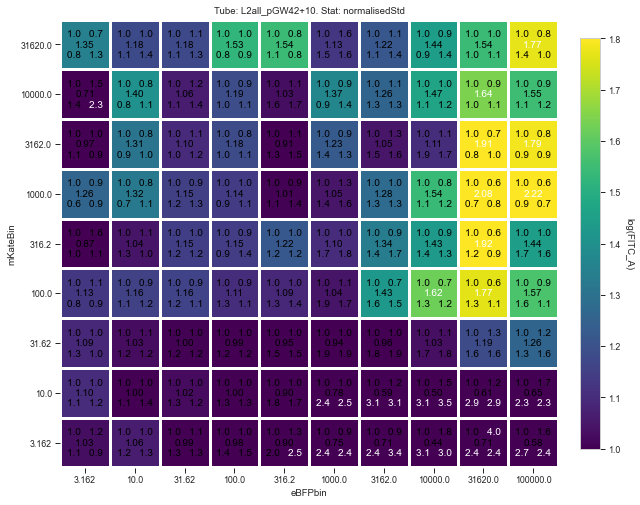

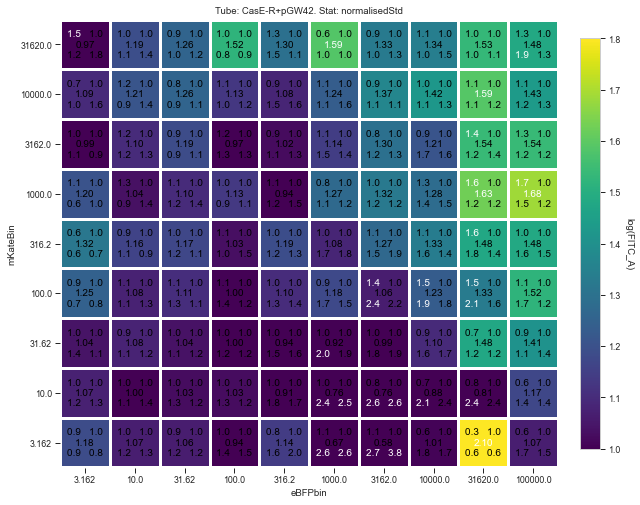

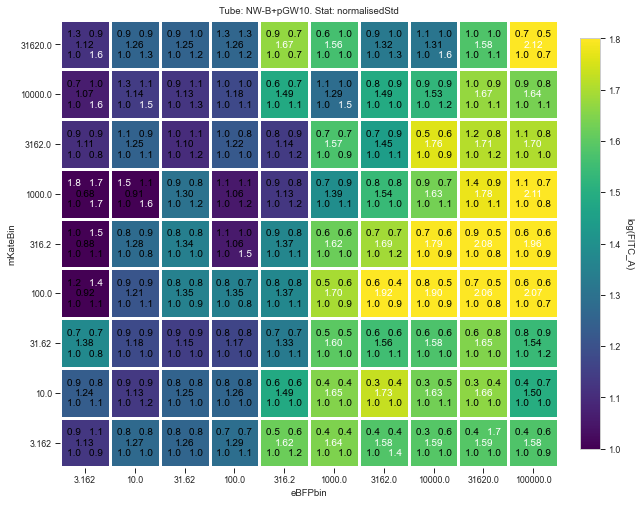

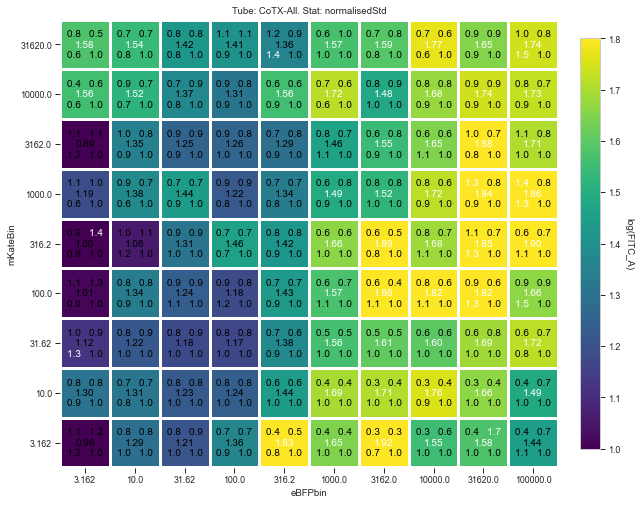

In [27]:
# enter these from list printed above
tube_names = ['L2all_pGW42+10',
              'CasE-R+pGW42',
              'NW-B+pGW10',
              'CoTX-All']

save_directory = os.path.join(os.getcwd(), 'test_outputs/figures/')


for name in tube_names:
    tube = flowgeo.subset(cell_singlets, ('TUBE_NAME', name))  # call each tube by name, and only select single cells
    '''
    @Jean: Possible entry point for you to do any kind of data processing.
    At this point the data of interest is converted to a numpy array. 
    '''
    x = list(np.sort(list(tube[x_name].unique())))[::-1]  # get data sorted from low to high (reverse list for heatmap ori bottom left)
    y = list(np.sort(list(tube[y_name].unique())))
    cut_args = {'x_min': 2, 'y_min': 2, 'x_max': 90000, 'y_max': 110000}  # xmax ymax wrong way around in flowgeo - haven't gotten around to sorting this yet lol
    x, y = flowgeo.cut_list(x, y, **cut_args)  # cut data on sides, where there weren't enough events


    common = (tube, x, x_name, y, y_name, z_name)  # some common parameters (axis names, current tube, x and y data)
    '''
    @Jean: Possible entry point for you to do any kind of data processing
    '''
    # create statistics
    arr_logmean = flowgeo.create_arr(
        *common, stat='normalisedStd', x_norm_names=['Pacific_Blue_A', 'PE_Texas_Red_A'])
    # arr_std = flowgeo.create_arr(*common, stat='CV')
    # arr_std *= 100

    comp_stat = 'normalisedStd'
    ctrl_arr = flowgeo.create_arr(
        *common, stat=comp_stat, x_norm_names=['Pacific_Blue_A', 'PE_Texas_Red_A'])
    # print(ctrl_arr)
    # print(np.shape(ctrl_arr))
    comp_arr_collection = np.ones((len(tube_names), *np.shape(ctrl_arr)))
    
    # print(np.shape(comp_arr_collection))
    # below is specific to the L1 vs L2 experiments, so you can create comparison stats between different tubes and keep track of them
    for i, comp_name in enumerate(tube_names):
        comp_tube = flowgeo.subset(cell_singlets, ('TUBE_NAME', comp_name))
        common_comp = (comp_tube, x, x_name, y, y_name, z_name)

        comp_arr = flowgeo.create_arr(
            *common_comp, stat=comp_stat, x_norm_names=['Pacific_Blue_A', 'PE_Texas_Red_A'])
        comp_arr /= ctrl_arr

        comp_arr_collection[i] = comp_arr

    # plotting
    save_path = f"{save_directory}/normCV_{name}.png"
    fig, ax = plt.subplots(figsize=(9,9))
    im, cbar = flowgeo.heatmap(np.log(arr_logmean), x, y, ax=ax,
                               cmap="viridis", cbarlabel=f"log({z_name})", vmin=1, vmax=1.8)

    # textsN creates an annotation in a corner of the heatmap square for any kind of comparison statistic created in `for i, comp_name in enumerate(tube_names)`
    texts1 = flowgeo.annotate_heatmap(
        im, data=comp_arr_collection[0], valfmt="{x:.1f}        \n\n")
    texts2 = flowgeo.annotate_heatmap(
        im, data=comp_arr_collection[1], valfmt="        {x:.1f}\n\n")
    texts3 = flowgeo.annotate_heatmap(
        im, data=comp_arr_collection[2], valfmt="\n\n{x:.1f}        ")
    texts4 = flowgeo.annotate_heatmap(
        im, data=comp_arr_collection[3], valfmt="\n\n        {x:.1f}")
    
    text_center = flowgeo.annotate_heatmap(
        im, data=(np.log(ctrl_arr)), valfmt="{x:.2f}")

    # print(ctrl_arr)

    ax.set_title(f"Tube: {name}. Stat: {comp_stat}")
    ax.set_ylabel("mKateBin")
    ax.set_xlabel("eBFPbin")
    plt.grid(False)
    fig.tight_layout()
    plt.savefig(save_path)
# print(arr_mean)
# print(arr_std)
